#インポート

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision

#シード固定

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#デバイス・データセット・モデル定義

In [3]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


class CNN_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.GroupNorm(8, 32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.GroupNorm(8, 64) 
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.GroupNorm(8, 128) 
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 100)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(100, 10)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y     

#学習率・エポック数・バッチサイズ指定、データローダー作る

In [4]:
set_seed(42)
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

LEARNING_RATE = 0.001
EPOCHS = 500

#学習ループ

In [5]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = LEARNING_RATE)

SGD_train_loss_history = []
SGD_test_loss_history = []
SGD_train_acc_history = []
SGD_test_acc_history = []
SGD_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0
    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    fg_count += 1
    train_loss /= len(train_loader)
    train_acc = correct / total

    SGD_x.append(fg_count)
    SGD_train_loss_history.append(train_loss)
    SGD_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    SGD_test_loss_history.append(test_loss)
    SGD_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 157/157 [00:01<00:00, 151.05it/s, loss=2.25, acc=0.207]


Train Loss: 2.2909, Acc: 0.1487 | Test Loss: 2.2686, Acc: 0.2069
epoch: 2


100%|██████████| 157/157 [00:01<00:00, 140.26it/s, loss=2.13, acc=0.21] 


Train Loss: 2.2345, Acc: 0.2065 | Test Loss: 2.1885, Acc: 0.2101
epoch: 3


...

Train Loss: 0.3547, Acc: 0.8768 | Test Loss: 0.9062, Acc: 0.7124
epoch: 499


100%|██████████| 157/157 [00:00<00:00, 163.93it/s, loss=0.747, acc=0.673]


Train Loss: 0.3541, Acc: 0.8777 | Test Loss: 1.0645, Acc: 0.6731
epoch: 500


100%|██████████| 157/157 [00:00<00:00, 164.56it/s, loss=0.63, acc=0.728] 

Train Loss: 0.3553, Acc: 0.8784 | Test Loss: 0.8766, Acc: 0.7282


##SVRG

In [6]:
set_seed(42)
class SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['hat_w'] = torch.clone(p)

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue


                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["w"])
                    if p.grad is None:
                        continue
                    state["snapshot_grad"] = torch.clone(p.grad.detach())


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                z = state['z']
                snapshot_grad = state["snapshot_grad"]
                v = grad - snapshot_grad + z
                p.sub_(v, alpha = lr)

        return loss

In [7]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = SVRG(model.parameters(), lr = LEARNING_RATE)

SVRG_train_loss_history = []
SVRG_test_loss_history = []
SVRG_train_acc_history = []
SVRG_test_acc_history = []
SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.calc_full_grads(model, train_loader, criterion)
    fg_count += 1

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.calc_snapshot_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    SVRG_x.append(fg_count)
    SVRG_train_loss_history.append(train_loss)
    SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    SVRG_test_loss_history.append(test_loss)
    SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 157/157 [00:00<00:00, 175.16it/s, loss=2.25, acc=0.209]


Train Loss: 2.2912, Acc: 0.1505 | Test Loss: 2.2697, Acc: 0.2095
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 170.37it/s, loss=2.13, acc=0.208]


Train Loss: 2.2359, Acc: 0.2081 | Test Loss: 2.1905, Acc: 0.2076
epoch: 3


...

Train Loss: 0.6715, Acc: 0.7632 | Test Loss: 0.9544, Acc: 0.6621
epoch: 166


100%|██████████| 157/157 [00:01<00:00, 151.57it/s, loss=0.841, acc=0.675]


Train Loss: 0.7018, Acc: 0.7536 | Test Loss: 0.9356, Acc: 0.6749
epoch: 167


100%|██████████| 157/157 [00:01<00:00, 154.99it/s, loss=0.697, acc=0.663]

Train Loss: 0.6950, Acc: 0.7540 | Test Loss: 0.9267, Acc: 0.6630


##No Full Grad SVRG

In [8]:
set_seed(42)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state['hat_w'] = torch.clone(p)

                state["a"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_w'] = torch.clone(p).detach()


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                hat_a = state["hat_a"]
                snapshot_grad = state["snapshot_grad"]
                t = state["t"]

                v = grad - snapshot_grad + hat_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [9]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

NFG_SVRG_train_loss_history = []
NFG_SVRG_test_loss_history = []
NFG_SVRG_train_acc_history = []
NFG_SVRG_test_acc_history = []
NFG_SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.calc_snapshot_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    optimizer.end_epoch()

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    NFG_SVRG_x.append(fg_count)
    NFG_SVRG_train_loss_history.append(train_loss)
    NFG_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    NFG_SVRG_test_loss_history.append(test_loss)
    NFG_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


  0%|          | 0/782 [00:00<?, ?it/s]

100%|██████████| 157/157 [00:00<00:00, 170.43it/s, loss=2.25, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3199, Acc: 0.0986
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 162.85it/s, loss=2.26, acc=0.212]


...

Train Loss: 1.8282, Acc: 0.2922 | Test Loss: 1.8204, Acc: 0.3043
epoch: 249


100%|██████████| 157/157 [00:00<00:00, 169.75it/s, loss=1.87, acc=0.306]


Train Loss: 1.8214, Acc: 0.2936 | Test Loss: 1.8133, Acc: 0.3059
epoch: 250


100%|██████████| 157/157 [00:00<00:00, 159.62it/s, loss=1.87, acc=0.307]

Train Loss: 1.8155, Acc: 0.2945 | Test Loss: 1.8079, Acc: 0.3066


##Primal No Full Grad SVRG

In [10]:
set_seed(42)
class ASAI_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["hat_z"] = torch.clone(p.detach())

                state["a"].zero_()
                state["z"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_z'].copy_(state["z"])


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                prev_a = state["hat_a"]
                prev_grad = state["snapshot_grad"]
                z = state["z"]
                t = state["t"]

                v = grad - prev_grad + prev_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [11]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = ASAI_SVRG(model.parameters(), lr = LEARNING_RATE)

ASAI_SVRG_train_loss_history = []
ASAI_SVRG_test_loss_history = []
ASAI_SVRG_train_acc_history = []
ASAI_SVRG_test_acc_history = []
ASAI_SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.calc_snapshot_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    optimizer.end_epoch()

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    ASAI_SVRG_x.append(fg_count)
    ASAI_SVRG_train_loss_history.append(train_loss)
    ASAI_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)

        backup = []
        with torch.no_grad():
            for group in optimizer.param_groups:
                for p in group['params']:
                    state = optimizer.state[p]
                    backup.append(p.clone())
                    p.copy_(state["z"])

        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        with torch.no_grad():
            i = 0
            for group in optimizer.param_groups:
                for p in group['params']:
                    p.copy_(backup[i])
                    i += 1

    test_loss /= len(test_loader)
    test_acc = correct / total

    ASAI_SVRG_test_loss_history.append(test_loss)
    ASAI_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


  0%|          | 0/782 [00:00<?, ?it/s, loss=2.34, acc=0.0781]

100%|██████████| 157/157 [00:00<00:00, 161.37it/s, loss=2.25, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3199, Acc: 0.0986
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 168.53it/s, loss=2.27, acc=0.136]


...

Train Loss: 0.5034, Acc: 0.8275 | Test Loss: 0.7047, Acc: 0.7512
epoch: 249


100%|██████████| 157/157 [00:01<00:00, 156.00it/s, loss=0.633, acc=0.751]


Train Loss: 0.5297, Acc: 0.8179 | Test Loss: 0.7038, Acc: 0.7515
epoch: 250


100%|██████████| 157/157 [00:01<00:00, 156.84it/s, loss=0.632, acc=0.752]

Train Loss: 0.4935, Acc: 0.8313 | Test Loss: 0.7042, Acc: 0.7525


In [14]:
set_seed(42)
class Polyak_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['hat_w'] = torch.clone(p)

                if "x" not in state:
                    state["x"] = torch.clone(p.detach())
                    state["hat_x"] = torch.clone(p.detach())

                state["x"].zero_()
                state["t"] = 0

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue


                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["w"])
                    if p.grad is None:
                        continue
                    state["snapshot_grad"] = torch.clone(p.grad.detach())


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state['hat_x'].copy_(state["x"])


    @torch.no_grad()
    def step(self, closure=None):
        loss = None

        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                z = state['z']
                x = state["x"]
                t = state["t"]
                snapshot_grad = state["snapshot_grad"]
                v = grad - snapshot_grad + z
                p.sub_(v, alpha = lr)
                x.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [15]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Polyak_SVRG(model.parameters(), lr = LEARNING_RATE)

Polyak_SVRG_train_loss_history = []
Polyak_SVRG_test_loss_history = []
Polyak_SVRG_train_acc_history = []
Polyak_SVRG_test_acc_history = []
Polyak_SVRG_x = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.calc_full_grads(model, train_loader, criterion)
    fg_count += 1

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.calc_snapshot_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})
    
    optimizer.end_epoch()

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    Polyak_SVRG_x.append(fg_count)
    Polyak_SVRG_train_loss_history.append(train_loss)
    Polyak_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)

        backup = []
        with torch.no_grad():
            for group in optimizer.param_groups:
                for p in group['params']:
                    state = optimizer.state[p]
                    backup.append(p.clone())
                    p.copy_(state["x"])

        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        with torch.no_grad():
            i = 0
            for group in optimizer.param_groups:
                for p in group['params']:
                    p.copy_(backup[i])
                    i += 1

    test_loss /= len(test_loader)
    test_acc = correct / total

    Polyak_SVRG_test_loss_history.append(test_loss)
    Polyak_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

    if fg_count >= EPOCHS:
        break

epoch: 1


100%|██████████| 157/157 [00:00<00:00, 171.29it/s, loss=2.27, acc=0.137]


Train Loss: 2.2912, Acc: 0.1505 | Test Loss: 2.2903, Acc: 0.1374
epoch: 2


100%|██████████| 157/157 [00:00<00:00, 170.96it/s, loss=2.2, acc=0.207] 


Train Loss: 2.2359, Acc: 0.2081 | Test Loss: 2.2357, Acc: 0.2074
epoch: 3


...

Train Loss: 0.6715, Acc: 0.7632 | Test Loss: 0.7666, Acc: 0.7294
epoch: 166


100%|██████████| 157/157 [00:01<00:00, 156.16it/s, loss=0.819, acc=0.73] 


Train Loss: 0.7018, Acc: 0.7536 | Test Loss: 0.7654, Acc: 0.7299
epoch: 167


100%|██████████| 157/157 [00:00<00:00, 159.03it/s, loss=0.819, acc=0.73] 

Train Loss: 0.6950, Acc: 0.7540 | Test Loss: 0.7642, Acc: 0.7302


#結果

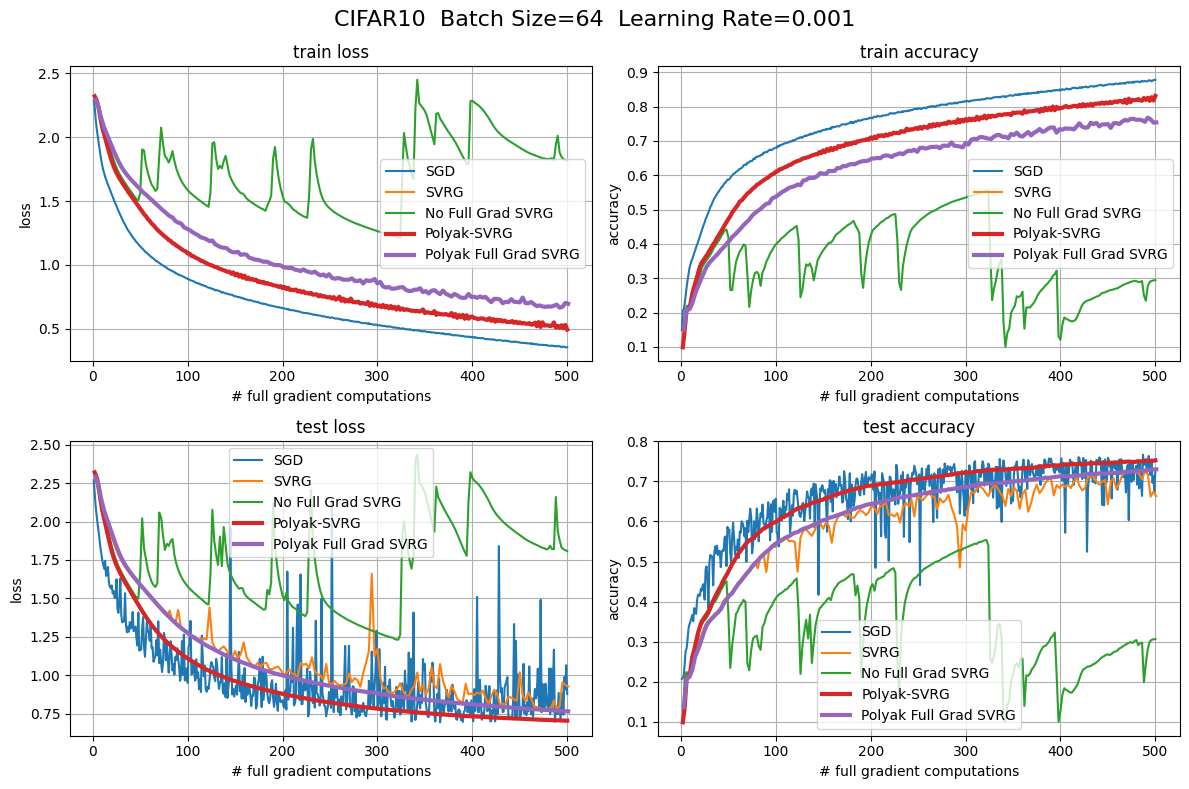

In [16]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"CIFAR10  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(2, 2, 1)
ax.plot(SGD_x, SGD_train_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_loss_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_loss_history, label = "Polyak Full Grad SVRG", linewidth = 3)

ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
ax.plot(SGD_x, SGD_train_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_train_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_train_acc_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_train_acc_history, label = "Polyak Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_loss_history, label = "Polyak Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
ax.plot(SGD_x, SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_acc_history, label = "Polyak-SVRG", linewidth = 3)
ax.plot(Polyak_SVRG_x, Polyak_SVRG_test_acc_history, label = "Polyak Full Grad SVRG", linewidth = 3)
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

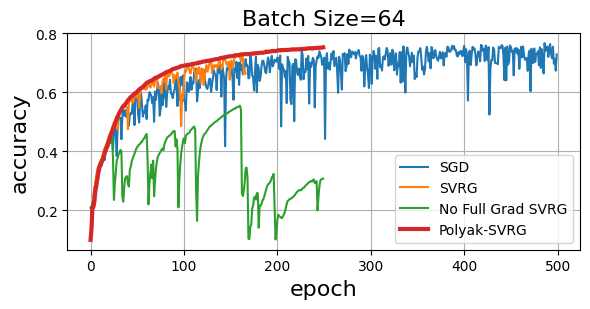

In [22]:
fig = plt.figure(figsize = (6, 3.2))
ax = fig.add_subplot()
ax.plot(SGD_test_acc_history, label = "SGD")
ax.plot(SVRG_test_acc_history, label = "SVRG")
ax.plot(NFG_SVRG_test_acc_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_test_acc_history, label = "Polyak-SVRG", linewidth = 3)
ax.set_xlabel("epoch", fontsize=16)
ax.set_ylabel("accuracy", fontsize=16)
ax.set_title(f"Batch Size={BATCH_SIZE}" ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

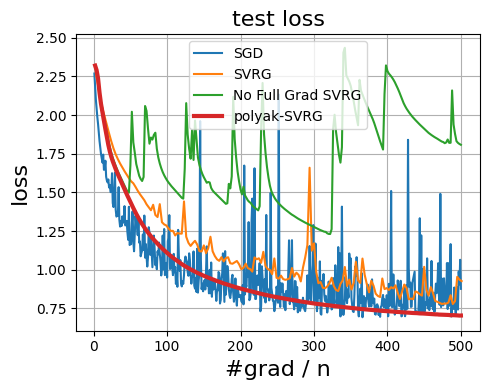

In [19]:
fig = plt.figure(figsize = (5, 4))
ax = fig.add_subplot()
ax.plot(SGD_x, SGD_test_loss_history, label = "SGD")
ax.plot(SVRG_x, SVRG_test_loss_history, label = "SVRG")
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG")
ax.plot(ASAI_SVRG_x, ASAI_SVRG_test_loss_history, label = "polyak-SVRG", linewidth = 3)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("loss", fontsize=16)
ax.set_title('test loss' ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()